In [1]:
import pickle
from probcs.models.pattern_completion_model import BinaryPatternCompletionModel

In [2]:
with open(f"results_natural_{10}_{500}.pkl", "rb") as f:
    results = pickle.load(f)

In [3]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
all_idata, G_dim, disrupting_pattern_indices = results

In [5]:
def plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata):
    """
    Modified function to plot bar plots of MEI, Completing, and Disrupting patterns for binary X
    in the same subplot for each latent variable G.

    Parameters:
    - G_dim (int): Dimension of the latent variable G.
    - disrupting_pattern_indices (list): List of indices corresponding to disrupting patterns.
    - all_idata (list): List containing InferenceData objects for MEI, Completing, and Disrupting 1 and Disrupting 2 patterns.

    Returns:
    - fig (matplotlib.figure.Figure): The Matplotlib figure object containing the generated plot.
    - axs (numpy.ndarray): 2D array of Matplotlib axes objects representing subplots in the figure.
    - completing_perc_diff_list (list): List of percentage differences for Completing.
    - disrupting_1_perc_diff_list (list): List of percentage differences for Disrupting 1.
    - disrupting_2_perc_diff_list (list): List of percentage differences for Disrupting 2.
    """

    fig, axs = plt.subplots(
        G_dim, 6, figsize=(6 * 8, 3 * 4), tight_layout=True, sharex="col", sharey="row"
    )
    legend_size = 6

    completing_perc_diff_list = []
    disrupting_1_perc_diff_list = []
    disrupting_2_perc_diff_list = []

    for idx, (ax_set, idata_set, disrupting_pattern_idx) in enumerate(
        zip(axs, all_idata, disrupting_pattern_indices)
    ):
        center_x_id = 4 * G_dim + idx

        # Collect probabilities for MEI, Completing, and Disrupting patterns
        center_probabilities = []
        all_probabilities = []
        for pattern_id, idata in enumerate(idata_set):
            x_prob = idata["posterior"]["X"].data[:, :, center_x_id].mean()
            center_probabilities.append(x_prob)
            all_x_prob = idata["posterior"]["X"].data.mean(axis=0).mean(axis=0)
            all_probabilities.append(all_x_prob)

            if pattern_id == 0:
                mei_x_prob = x_prob
            elif pattern_id > 0:
                perc_diff = (x_prob - mei_x_prob) / mei_x_prob * 100
                if pattern_id == 1:
                    completing_perc_diff_list.append(perc_diff)
                elif pattern_id == 2:
                    disrupting_1_perc_diff_list.append(perc_diff)
                elif pattern_id == 3:
                    disrupting_2_perc_diff_list.append(perc_diff)
            # if idx == 3:
            #     print(idata["posterior"]["X"].data[:, :, center_x_id])
            #     print(center_probabilities)

        # Plot center_probabilities in the same subplot for comparison
        ax_set[0].bar(
            ["MEI", "Completing", "Disrupting 1", "Disrupting 2"],
            center_probabilities,
            color=["blue", "green", "orange", "red"],
        )
        ax_set[0].set_ylim(0, 1)  # Probabilities range from 0 to 1

        # Plot all_probabilities in the same subplot for comparison
        for idx, probs in enumerate(all_probabilities):
            ax_set[2 + idx].bar(
                list(range(G_dim * 9)),
                probs,
                color=["red" if i == center_x_id else "blue" for i in range(G_dim * 9)],
            )
            ax_set[2 + idx].set_xticks(list(range(G_dim * 9)))
            ax_set[2 + idx].set_xticklabels(list(range(G_dim * 9)))

        # Plot G distributions (unchanged)
        mei_g_samples = idata_set[0]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        completing_g_samples = (
            idata_set[1]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )
        disrupting_1_g_samples = (
            idata_set[2]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )
        disrupting_2_g_samples = (
            idata_set[3]["posterior"]["G"].data.mean(axis=0).mean(axis=0)
        )

        ax_set[1].bar(x=np.arange(G_dim), height=mei_g_samples, width=0.8, color="blue")
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim,
            height=completing_g_samples,
            width=0.8,
            color="green",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 2,
            height=disrupting_1_g_samples,
            width=0.8,
            color="orange",
        )
        ax_set[1].bar(
            x=np.arange(G_dim) + G_dim * 3,
            height=disrupting_2_g_samples,
            width=0.8,
            color="red",
        )
        ax_set[1].set_xticks(np.arange(G_dim * 4))
        ax_set[1].set_xticklabels(list(np.arange(G_dim)) * 4)

    completing_perc_diff_list = np.array(completing_perc_diff_list)
    disrupting_1_perc_diff_list = np.array(disrupting_1_perc_diff_list)
    disrupting_2_perc_diff_list = np.array(disrupting_2_perc_diff_list)

    return (
        fig,
        axs,
        completing_perc_diff_list,
        disrupting_1_perc_diff_list,
        disrupting_2_perc_diff_list,
    )

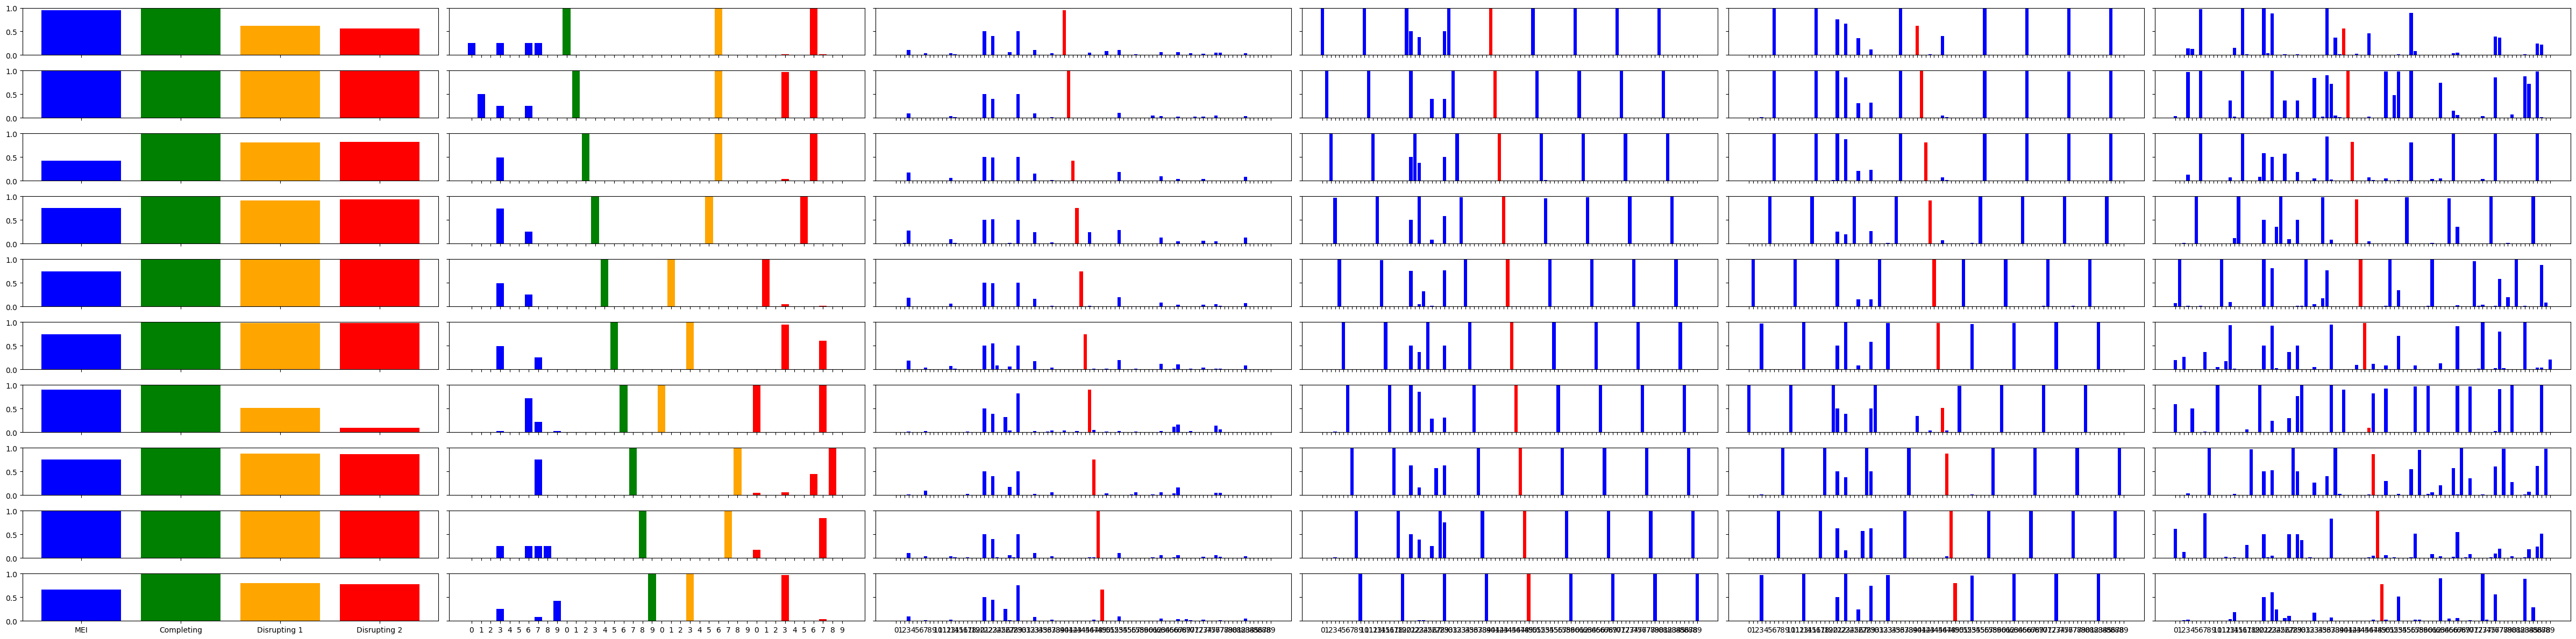

In [6]:
(
    fig,
    axs,
    completing_perc_diff_list,
    disrupting_1_perc_diff_list,
    disrupting_2_perc_diff_list,
) = plot_posterior_binary(G_dim, disrupting_pattern_indices, all_idata)

In [7]:
from probcs.utils.utils import get_natural_images

In [8]:
images = get_natural_images()
vmin = images.min()
vmax = images.max()

In [9]:
patterns = images[:10]

In [10]:
G_dim = len(patterns)
G_prob = 0.5
# I_sigma = 170
I_sigma = 200
patterns_offset = 0

g_x_mapping = np.zeros((G_dim * 9, G_dim)) + 0.05
for j in range(0, G_dim * 9, G_dim):
    for i in range(G_dim):
        g_x_mapping[i + j, i] = 0.8

G_visual_nrows = G_dim
G_visual_ncols = 1
x_visual_nrows = G_dim
x_visual_ncols = 9
n_tune = 500
n_draws = 500
n_chains = 4
n_cores = 4

In [11]:
model = BinaryPatternCompletionModel(
    patterns=patterns,
    G_prob=G_prob,
    I_sigma=I_sigma,
    patterns_offset=patterns_offset,
    g_x_mapping=g_x_mapping,
)

array([[[ 61.73,  57.02,  60.7 , ...,   0.  ,   0.  ,   0.  ],
        [ 50.53,  55.03,  55.38, ...,   0.  ,   0.  ,   0.  ],
        [ 48.04,  49.73,  60.34, ...,   0.  ,   0.  ,   0.  ],
        ...,
        [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ]],

       [[133.73, 133.02, 131.7 , ...,   0.  ,   0.  ,   0.  ],
        [115.53, 104.03,  82.38, ...,   0.  ,   0.  ,   0.  ],
        [ -8.96, -30.27, -44.66, ...,   0.  ,   0.  ,   0.  ],
        ...,
        [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ],
        [  0.  ,   0.  ,   0.  , ...,   0.  ,   0.  ,   0.  ]],

       [[-37.27,  -6.98,  -5.3 , ...,   0.  ,   0.  ,   0.  ],
        [-22.47, -11.97,  22.38, ...,   0.  ,   0.  ,   0.  ],
        [ -1.96,   1.73,   1.34, ...,   0.  ,   0.  ,   0.  ],
        ...,
        [  0

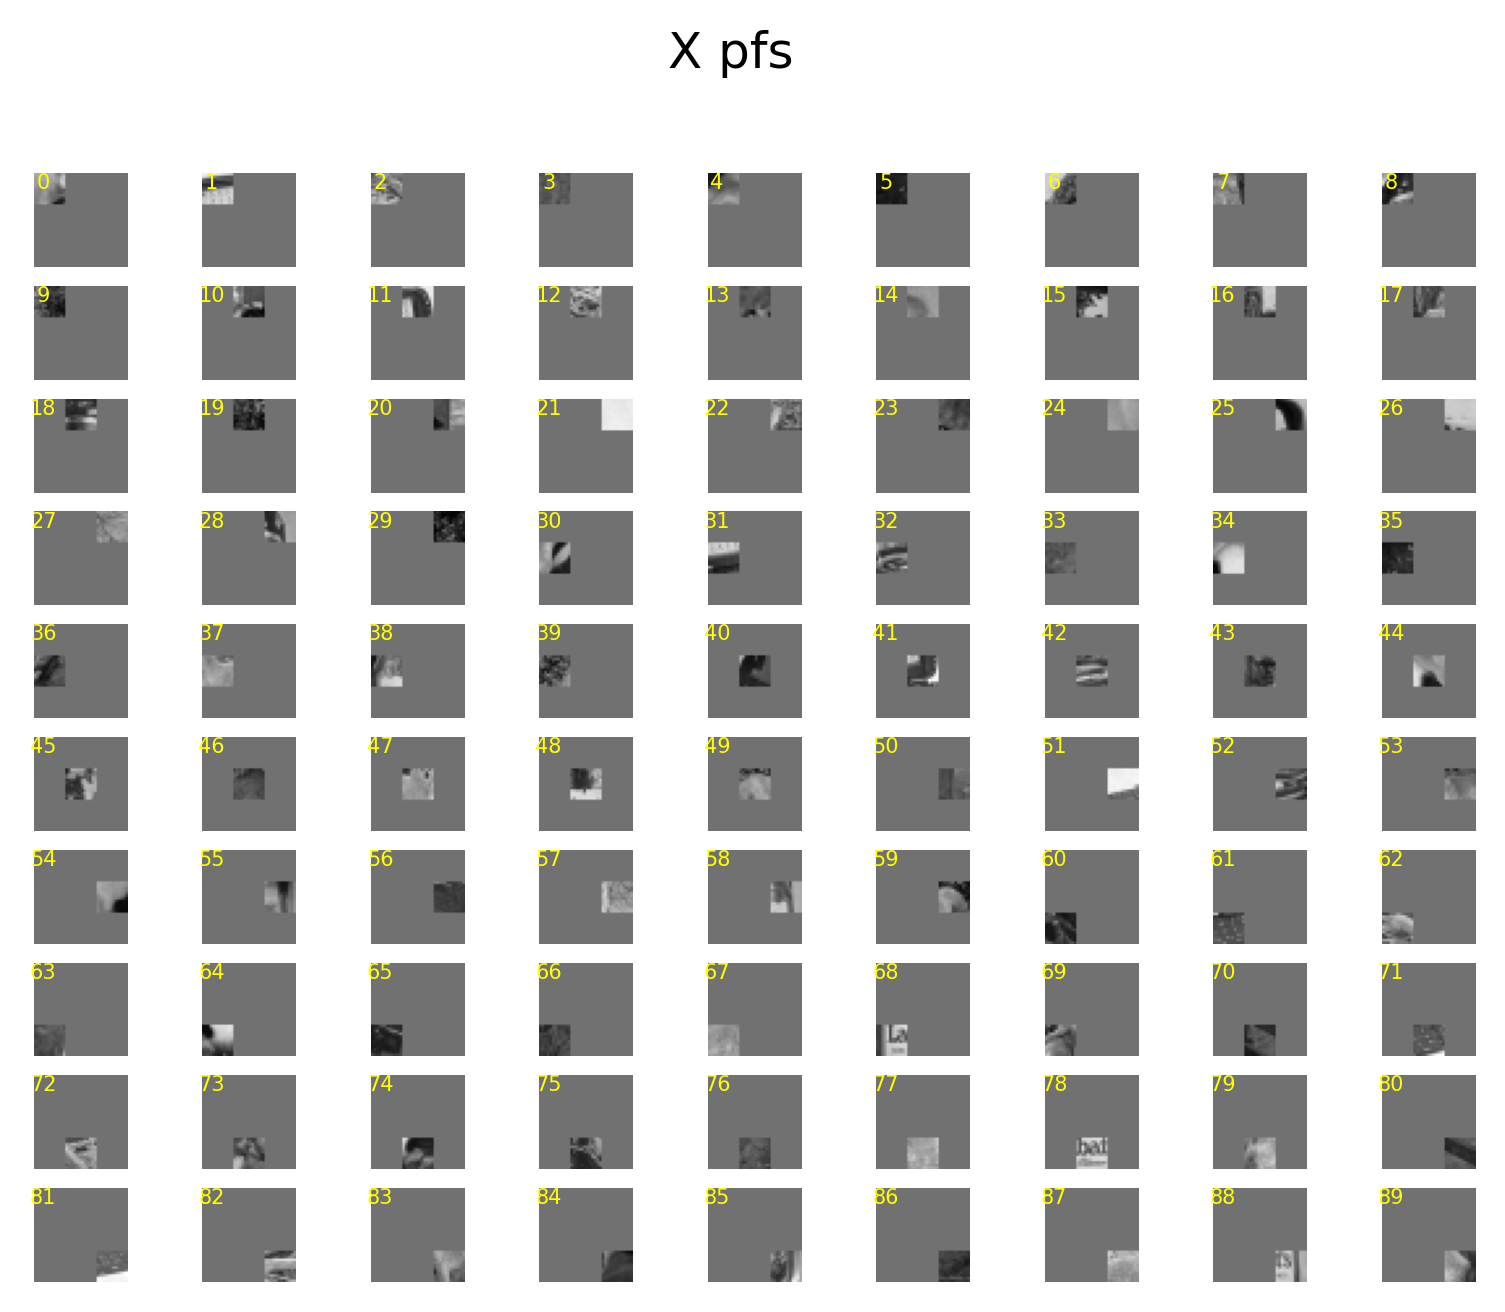

In [12]:
model.visualize_learned_X(x_visual_nrows, x_visual_ncols)